# Data Loading & Exploration Notebook

The purpose of this module is to explore the multimodal skin cancer detection data\.  

### Import Libraries

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt

from mra_midas_skin_cancer_ml.utils.process_metadata import (
    import_metadata,
    process_target,
    export_metadata,
    dedupe_metadata
)

from mra_midas_skin_cancer_ml.utils.nlp_functions import (
    basic_clean_clinical_text, 
    add_note_embeddings_tfidf_svd,
    svd_top_phrases,
)

### Data Loading

Data comes from Stanford's MR\-MIDAS: https://stanfordaimi\.azurewebsites\.net/datasets/f4c2020f\-801a\-42dd\-a477\-a1a8357ef2a5

1\. Each user signed the data research use agreement\. 

2\. The dataset was downloaded using Azure Explorer\. 

In [3]:
df = import_metadata()
df

,Unnamed: 0,midas_record_id,midas_file_name,midas_iscontrol,midas_distance,midas_location,midas_path,midas_pathreport,midas_gender,midas_age,midas_fitzpatrick,midas_melanoma,midas_ethnicity,midas_race,clinical_impression_1,clinical_impression_2,clinical_impression_3,length_(mm),width_(mm)
0,0,1,s-prd-398966407.jpg,no,1ft,chest,malignant- sccis,"focal squamous cell carcinoma, in situ, aris...",female,80,"ii fair skin, blue eyes",no,no,white,7-malignant-bcc,6-benign-other,1-benign-melanocytic nevus,8.0,5.0
1,1,1,s-prd-398966642.jpg,no,6in,chest,malignant- sccis,"focal squamous cell carcinoma, in situ, aris...",female,80,"ii fair skin, blue eyes",no,no,white,7-malignant-bcc,6-benign-other,1-benign-melanocytic nevus,8.0,5.0
2,2,1,s-prd-398966845.jpg,no,dscope,chest,malignant- sccis,"focal squamous cell carcinoma, in situ, aris...",female,80,"ii fair skin, blue eyes",no,no,white,7-malignant-bcc,6-benign-other,1-benign-melanocytic nevus,8.0,5.0
3,3,1,s-prd-398967381.jpg,no,1ft,l lower back,benign-melanocytic nevus,"intradermal melanocytic nevus, transected at t...",female,80,"ii fair skin, blue eyes",no,no,white,1-benign-melanocytic nevus,6-benign-other,6-benign-other,6.0,5.0
4,4,1,s-prd-398967587.jpg,no,dscope,l lower back,benign-melanocytic nevus,"intradermal melanocytic nevus, transected at t...",female,80,"ii fair skin, blue eyes",no,no,white,1-benign-melanocytic nevus,6-benign-other,6-benign-other,6.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3411,3411,814,s-prd-840869645.jpeg,yes,n/a - virtual,back,NaN,0,male,60,"ii fair skin, blue eyes",yes,no,white,2-benign-seborrheic keratosis,1-benign-melanocytic nevus,NaN,6.0,5.0
3412,3412,814,s-prd-840869646.jpeg,yes,n/a - virtual,back,NaN,0,male,60,"ii fair skin, blue eyes",yes,no,white,2-benign-seborrheic keratosis,1-benign-melanocytic nevus,NaN,6.0,5.0
3413,3413,815,s-prd-856668096.jpg,no,dscope,lower back,benign-melanocytic nevus,"mildly dysplastic compound melanocytic nevus, ...",female,52,"i pale white skin, blue/green eyes, blond/red ...",no,no,white,1-benign-melanocytic nevus,11-malignant-melanoma,1-benign-melanocytic nevus,10.0,9.0
3414,3414,815,s-prd-856665590.jpg,no,6in,lower back,benign-melanocytic nevus,"mildly dysplastic compound melanocytic nevus, ...",female,52,"i pale white skin, blue/green eyes, blond/red ...",no,no,white,1-benign-melanocytic nevus,11-malignant-melanoma,1-benign-melanocytic nevus,10.0,9.0


### Data Exploration

Target Variable:

- midas\_path\_binary: Target variable for most hypotheses\. Imputed in Jeremy's process\_target function\.

Potential Data Leakage:

- clinical\_impression\_1 through clinical\_impression\_3 fields: Section 2\.2 explains that clinical impressions are recorded before biopsy and later compared to pathology results\. These fields reflect dermatologist judgment and expert priors, so using them as model inputs would give the model access to human diagnostic reasoning it wouldn’t have at prediction time\.

- midas\_path and midas\_pathreport: Section 4\.3 describes these as pathology results from biopsied lesions\. Pathology is fine to use as a ground\-truth label, but using pathology report content or pathology\-derived fields as inputs would be clear target leakage, since that information only exists after the diagnostic decision\.

- midas\_iscontrol: Sections 2\.1 and 4\.1 describe these as non\-biopsied lesions and/or lesions that appear clinically benign, which relies on a clinical impression and can introduce implicit data leakage\.

Records:

- midas\_record\_id: Patient ID

- unique\_lesion\_id: This needs to be created since there are three images per lesion and there can be multiple lesions per patient\. 

- midas\_gender: For a given patient, this field is not accurate\. 

In [4]:
result_df = process_target(df)
metadata_df = dedupe_metadata(result_df)
metadata_df

Is unique: True
Unique count: 1146 



,midas_path_binary,midas_record_id,midas_location,midas_age,midas_fitzpatrick,midas_ethnicity,midas_race,length_(mm),width_(mm),lesion_key
row_id,,,,,,,,,,
0,malignant,1,chest,80,"ii fair skin, blue eyes",no,white,8.0,5.0,1_chest_8.0x5.0
1,benign,1,l lower back,80,"ii fair skin, blue eyes",no,white,6.0,5.0,1_l lower back_6.0x5.0
2,benign,1,left upper buttock,80,"ii fair skin, blue eyes",no,white,5.0,3.0,1_left upper buttock_5.0x3.0
3,benign,2,right upper eyelid,34,"ii fair skin, blue eyes",no,white,4.0,2.0,2_right upper eyelid_4.0x2.0
4,benign,3,left forearm,68,"ii fair skin, blue eyes",no,white,5.0,3.0,3_left forearm_5.0x3.0
...,...,...,...,...,...,...,...,...,...,...
1141,malignant,806,l leg,64,"ii fair skin, blue eyes",no,white,8.0,5.0,806_l leg_8.0x5.0
1142,malignant,807,right calf,65,"ii fair skin, blue eyes",no,white,4.5,3.0,807_right calf_4.5x3.0
1143,benign,809,back,64,"ii fair skin, blue eyes",no,white,5.0,5.0,809_back_5.0x5.0


### Metadata Profiling

In [5]:
def profile_df(df: pd.DataFrame, top_n: int = 10) -> dict:
    out = {}
    out["shape"] = df.shape
    out["memory_mb"] = df.memory_usage(deep=True).sum() / (1024**2)

    dtypes = df.dtypes.astype(str)
    missing = df.isna().sum()
    missing_pct = (missing / len(df)).round(4)
    nunique = df.nunique(dropna=True)

    overview = pd.DataFrame({
        "dtype": dtypes,
        "missing": missing,
        "missing_pct": missing_pct,
        "nunique": nunique,
        "nunique_pct": (nunique / len(df)).round(4),
    }).sort_values(["missing", "nunique"], ascending=False)

    out["overview"] = overview

    # Numeric summary
    num_cols = df.select_dtypes(include=[np.number]).columns
    if len(num_cols) > 0:
        out["numeric_describe"] = df[num_cols].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]).T

    # Object/text-ish summary (top values)
    obj_cols = df.select_dtypes(include=["object", "string", "category"]).columns
    topvals = {}
    for c in obj_cols:
        vc = df[c].value_counts(dropna=False).head(top_n)
        topvals[c] = vc
    out["top_values"] = topvals

    # Duplicates
    out["duplicate_rows"] = int(df.duplicated().sum())

    return out


In [6]:
prof = profile_df(metadata_df)
prof["shape"], prof["memory_mb"]

((1146, 10), 0.49951934814453125)

In [7]:
prof["overview"].head(30)

,dtype,missing,missing_pct,nunique,nunique_pct
midas_fitzpatrick,object,10,0.0087,6,0.0052
length_(mm),float64,5,0.0044,38,0.0332
width_(mm),float64,5,0.0044,29,0.0253
lesion_key,object,0,0.0000,1146,1.0000
midas_record_id,int64,0,0.0000,733,0.6396
midas_location,object,0,0.0000,497,0.4337
midas_age,int64,0,0.0000,75,0.0654
midas_race,object,0,0.0000,6,0.0052
midas_path_binary,object,0,0.0000,3,0.0026
midas_ethnicity,object,0,0.0000,3,0.0026


In [8]:
prof["numeric_describe"].head(20)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
midas_record_id,1146.0,355.696335,232.799174,1.0,6.45,27.25,155.25,328.5,551.0,750.75,797.05,815.0
midas_age,1146.0,62.910122,16.324754,21.0,26.45,32.00,53.00,66.0,75.0,86.00,93.00,99.0
length_(mm),1141.0,7.042770,5.216678,0.0,0.00,3.00,4.00,6.0,9.0,15.00,23.80,80.0
width_(mm),1141.0,5.807187,4.582631,0.0,0.00,2.00,4.00,5.0,7.0,11.00,20.00,80.0


In [9]:
prof["top_values"]["midas_fitzpatrick"]

midas_fitzpatrick
ii fair skin, blue eyes                               933
iii darker white skin                                  97
i pale white skin, blue/green eyes, blond/red hair     51
iv light brown skin                                    47
NaN                                                    10
v brown skin                                            5
vi dark brown or black skin                             3
Name: count, dtype: int64

In [10]:
prof["top_values"]["midas_race"]

midas_race
white                               984
asian                                60
other                                55
unknown                              36
black or african american             9
american indian or alaska native      2
Name: count, dtype: int64

In [11]:
prof["top_values"]["midas_ethnicity"]

midas_ethnicity
no         1064
yes          49
unknown      33
Name: count, dtype: int64

### NLPs on the High Cardinality Field

In [12]:
# Show unique values for selected columns from metadata_df
selected_cols = ['midas_location']
unique_values = {col: sorted(metadata_df[col].dropna().unique().tolist()) for col in selected_cols}
unique_values

{'midas_location': ['abdomen',
  'arm',
  'back',
  'central chest',
  'central chest\xa0',
  'central lower back',
  'central upper abdomen',
  'central upper back',
  'central upper back\xa0',
  'cheek',
  'chest',
  'chin',
  'crown of scalp',
  'crown of scalp\xa0',
  'forehead',
  'frontal scalp',
  'hypogastric region',
  'l 2nd finger',
  'l 5th finger',
  'l abdomen',
  'l abdomen\xa0',
  'l alar crease',
  'l anterior lower leg',
  'l anterior neck',
  'l anterior thigh',
  'l antihelix',
  'l arm',
  'l arm\xa0',
  'l axilla',
  'l back',
  'l breast',
  'l calf',
  'l cheek',
  'l cheek\xa0',
  'l chest',
  'l chest lateral',
  'l chest medial',
  'l chest\xa0',
  'l clavicle',
  'l crown of scalp',
  'l deltoid',
  'l dorsal 2nd toe',
  'l dorsal foot',
  'l dorsal forearm',
  'l dorsal hand',
  'l dorsal hand\xa0',
  'l ear',
  'l ear scapha',
  'l elbow',
  'l eyebrow',
  'l flank',
  'l flank inferior',
  'l flank superior',
  'l foot',
  'l forearm',
  'l forearm\xa0',


In [13]:
# Example of NLP with five components on midas_location
metadata_nlp, note_model = add_note_embeddings_tfidf_svd(
    metadata_df,
    text_col="midas_location",
    out_prefix="midas_location_svd",
    n_components=5,
    max_features=1000,
    ngram_range=(1, 1),
    min_df=2,
    max_df=0.9,
)
metadata_nlp

,midas_path_binary,midas_record_id,midas_location,midas_age,midas_fitzpatrick,midas_ethnicity,midas_race,length_(mm),width_(mm),lesion_key,midas_location_svd_000,midas_location_svd_001,midas_location_svd_002,midas_location_svd_003,midas_location_svd_004
row_id,,,,,,,,,,,,,,,
0,malignant,1,chest,80,"ii fair skin, blue eyes",no,white,8.0,5.0,1_chest_8.0x5.0,0.050672,0.084766,0.309894,0.012822,-0.190035
1,benign,1,l lower back,80,"ii fair skin, blue eyes",no,white,6.0,5.0,1_l lower back_6.0x5.0,0.594629,0.049519,-0.443316,0.085678,-0.221738
2,benign,1,left upper buttock,80,"ii fair skin, blue eyes",no,white,5.0,3.0,1_left upper buttock_5.0x3.0,0.231621,0.110421,0.303841,-0.029624,-0.160961
3,benign,2,right upper eyelid,34,"ii fair skin, blue eyes",no,white,4.0,2.0,2_right upper eyelid_4.0x2.0,0.238816,0.145199,0.274213,0.077537,0.037728
4,benign,3,left forearm,68,"ii fair skin, blue eyes",no,white,5.0,3.0,3_left forearm_5.0x3.0,0.096579,0.437439,0.160362,0.585418,0.105077
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1141,malignant,806,l leg,64,"ii fair skin, blue eyes",no,white,8.0,5.0,806_l leg_8.0x5.0,0.021824,0.114663,-0.147267,0.097456,-0.230462
1142,malignant,807,right calf,65,"ii fair skin, blue eyes",no,white,4.5,3.0,807_right calf_4.5x3.0,0.060665,0.280534,0.011537,0.200122,-0.000315
1143,benign,809,back,64,"ii fair skin, blue eyes",no,white,5.0,5.0,809_back_5.0x5.0,0.807610,-0.110771,-0.242938,-0.009272,0.085708


In [14]:
# Top phrases for each component
top = svd_top_phrases(note_model, top_n=15, component_ids=[0,1,2,3,4])
top

,component,direction,rank,phrase,weight
15,0,negative,1,deltoid,-6.162125e-11
16,0,negative,2,wrist,-3.363782e-11
17,0,negative,3,antihelix,-1.695994e-11
18,0,negative,4,hip,-4.060028e-12
19,0,negative,5,axilla,1.149347e-12
...,...,...,...,...,...
130,4,positive,11,proximal,8.369978e-04
131,4,positive,12,supra,3.413534e-04
132,4,positive,13,jaw,3.186260e-04
133,4,positive,14,chin,2.741893e-04


### Categorical Correlation

In [15]:
# Cramer's V for categorical correlation
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    
    return np.sqrt(chi2 / (n * (min(k - 1, r - 1))))

# Categorical columns
categorical_cols = ['midas_race', 'midas_ethnicity', 'midas_fitzpatrick']

# Drop missing values
df_cat = metadata_df[categorical_cols].dropna()

# Compute Cramér's V matrix
cramers_matrix = pd.DataFrame(
    np.zeros((len(categorical_cols), len(categorical_cols))),
    index=categorical_cols,
    columns=categorical_cols
)

for col1 in categorical_cols:
    for col2 in categorical_cols:
        cramers_matrix.loc[col1, col2] = cramers_v(df_cat[col1], df_cat[col2])

cramers_matrix

,midas_race,midas_ethnicity,midas_fitzpatrick
midas_race,1.000000,0.642336,0.485355
midas_ethnicity,0.642336,1.000000,0.271470
midas_fitzpatrick,0.485355,0.271470,1.000000


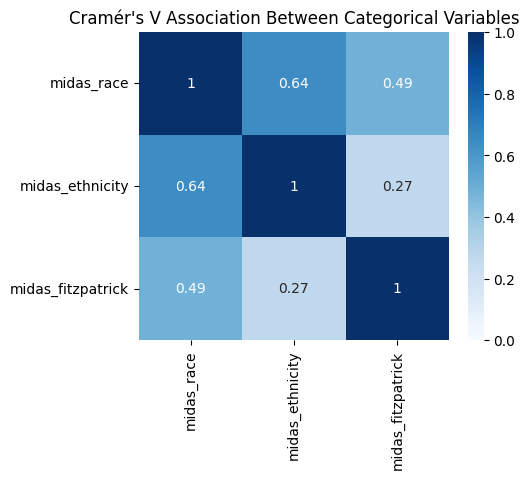

In [16]:
plt.figure(figsize=(5,4))
sns.heatmap(cramers_matrix, annot=True, cmap="Blues", vmin=0, vmax=1)
plt.title("Cramér's V Association Between Categorical Variables")
plt.show()

It's not clear what midas\_ethnicity is measuring\. midas\_ethnicity also has a moderate correlation with midas\_race\. Recommendation to exclude it from the modeling\.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=82a37552-7c08-4009-87b3-14968bdb21f2' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>